In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기
연봉이 5만달러 이상인지 아닌지

* age: 나이
* workclass: 고용형태
* education: 학력
* education-num: 교육연수
* marital-status: 혼인상태
* occupation: 직업
* relationship: 가족관계
* race: 인종
* sex: 성별
* capital-gain: 자산증가
* capital-loss: 자산감소
* hours-per-week: 주당 노동 시간
* native-country: 본국
* class: 연봉구분 - target(분석대상)

In [2]:
data = pd.read_csv('./data/salary2.csv')
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [4]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [5]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [6]:
data['occupation'].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [7]:
# workclass, occupation, native-country는 최빈값으로 대체
data.loc[data['workclass'].isna(),'workclass'] = data['workclass'].mode()[0]
data.loc[data['occupation'].isna(),'occupation'] = data['occupation'].mode()[0]
data.loc[data['native-country'].isna(),'native-country'] = data['native-country'].mode()[0]

In [8]:
data.isna().sum()

age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64

In [9]:
data = data.drop(['capital-gain','capital-loss'], axis=1)

In [10]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K
4,18,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,20,United-States,<=50K


<Axes: xlabel='hours-per-week'>

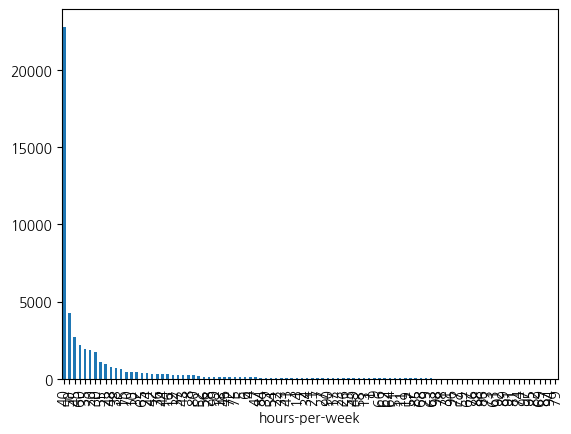

In [11]:
# box_plot으로 이상치 쉽게 확인
data['hours-per-week'].value_counts().plot(kind='bar')

In [12]:
hpw = data['hours-per-week'].describe()

In [13]:
upper = hpw['75%'] + (1.5*(hpw['75%'] - hpw['25%']))
lower = hpw['75%'] - (1.5*(hpw['75%'] - hpw['25%']))

In [14]:
data.loc[data['hours-per-week'] > upper, 'hours-per-week'] = hpw['75%']
data.loc[data['hours-per-week'] < lower, 'hours-per-week'] = hpw['25%']

In [15]:
data['sex'].apply(lambda x: 0 if x == 'Male' else 1)

0        1
1        1
2        1
3        1
4        1
        ..
48837    1
48838    1
48839    1
48840    1
48841    1
Name: sex, Length: 48842, dtype: int64

In [16]:
data['relationship'].value_counts()

relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

In [17]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K
4,18,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,40,United-States,<=50K


In [18]:
data['age'] = pd.cut(data['age'],
       bins=[0,10,20,30,40,50,60,70,80,90],
       labels = ['under10s', '10s','20s','30s','40s','50s','60s','70s','80s'])

# 해설

In [19]:
data = pd.read_csv('./data/salary2.csv')
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [20]:
data2 = data.copy()

In [21]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# 결측값 탐색

In [22]:
data.isna().sum() / len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [23]:
# 전체에서 5만달러 이상인 사람의 비율과
# workclass. occupation이 na인 사람들 중 5만달러 이상인 사람의 비율이 같으면 행 삭제 가능
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [24]:
data[data['workclass'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [25]:
data[data['occupation'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [26]:
# workclass가 NaN인 모든 행은 occupation도 NaN이다.
# 이 행들은 5만달러 이하 비중이 큼
data[(data['workclass'].isna()) & (data['occupation']).isna()]['class'].value_counts()

class
<=50K    2534
>50K      265
Name: count, dtype: int64

### 결측값의 비율이 약 5%, 삭제 시 데이터 분포에 편향을 주지 않으므로 Na값 모두 삭제

In [27]:
data = data.dropna()
data = data.reset_index(drop=True)

In [28]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# 이상치 탐색

In [29]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [30]:
# 그냥 별로인 데이터값처럼 보였으나, 99999, 15024 등 특정 값이 많은 경우가 있음
# 투자를 잘 해서 잘 벌었을지도
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
22040        1
7262         1
1639         1
1731         1
2387         1
Name: count, Length: 121, dtype: int64

#### 이상값으로 알아볼만한 무언가는 없다고 생각

# EDA
* 범주형 컬럼과 숫자형 컬럼을 따로 구분하여 파악
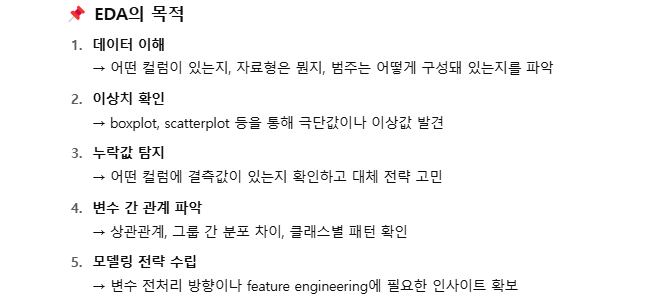

In [31]:
# 분석 위해 5만달러 이상은 1로 변경
data['class'] = data['class'].apply(lambda x: 1 if x == ' >50K' else 0)

In [32]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

### 범주형 변수들 EDA

In [33]:
# class와 변수간의 관계 분석 -> 고소득과의 관계 분석
for col in obj_cols:
    print('='*30, col,'='*30)
    print(col, obj_cols[col].nunique())  # 종류 몇개인지 확인
    print()
    print(obj_cols[col].value_counts())
    print()
    print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    print()

============================== workclass ==============================
workclass 7

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education 16

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name

In [34]:
# 40% 이상인 값이 있는 컬럼만 추출하기 위한 작업
ratio_result = data[['education','class']].groupby('education').mean().sort_values(by='class', ascending=False)
ratio_result

,class
education,
Prof-school,0.754140
Doctorate,0.733456
Masters,0.554097
Bachelors,0.419815
Assoc-acdm,0.264101
Assoc-voc,0.257274
Some-college,0.201030
HS-grad,0.163431
12th,0.074523


In [35]:
# 주요 값 판단 과정
ratio_result[ratio_result['class']>0.4].index

Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education')

In [36]:
# 컬럼 별로 주요한 값을 하나의 리스트에 정리
important_cols = []
for col in obj_cols:
    print('='*30, col,'='*30)
    print(col, obj_cols[col].nunique())  # 종류 몇개인지 확인
    print()
    print(obj_cols[col].value_counts())
    print()
    print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    print()
    ratio_result = data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class']>0.4].index)


============================== workclass ==============================
workclass 7

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education 16

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name

In [37]:
important_cols

[Index([' Self-emp-inc'], dtype='object', name='workclass'),
 Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education'),
 Index([' Married-civ-spouse', ' Married-AF-spouse'], dtype='object', name='marital-status'),
 Index([' Exec-managerial', ' Prof-specialty'], dtype='object', name='occupation'),
 Index([' Wife', ' Husband'], dtype='object', name='relationship'),
 Index([], dtype='object', name='race'),
 Index([], dtype='object', name='sex'),
 Index([' Taiwan', ' France', ' India'], dtype='object', name='native-country')]

In [38]:
# 값이 있는 컬럼만 다시 정리
final_cols = []

for col in important_cols:
    if len(col) > 0:
        print(col.name, '\t',len(col))
        final_cols.append(col.name)
        
final_cols

workclass 	 1
education 	 4
marital-status 	 2
occupation 	 2
relationship 	 2
native-country 	 3


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country']

### 수치형 변수들  EDA

============================== age ==============================
age count    45222.000000
mean        38.547941
std         13.217870
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64



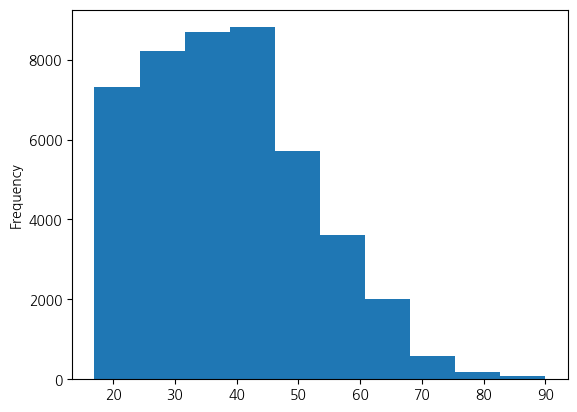


        class
age          
50   0.436671
53   0.404935
51   0.404790
54   0.404110
46   0.403955
..        ...
18   0.000000
82   0.000000
87   0.000000
86   0.000000
89   0.000000

[74 rows x 1 columns]


============================== education-num ==============================
education-num count    45222.000000
mean        10.118460
std          2.552881
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64



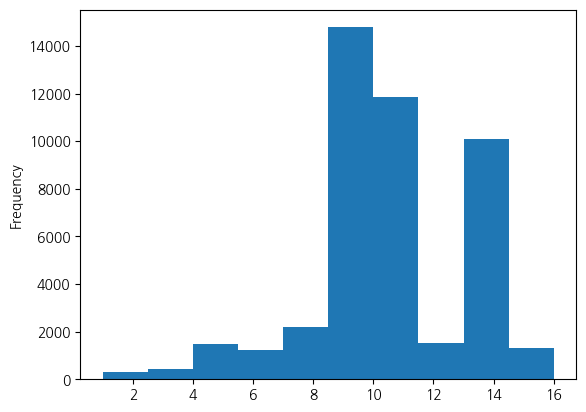


                  class
education-num          
15             0.754140
16             0.733456
14             0.554097
13             0.419815
12             0.264101
11             0.257274
10             0.201030
9              0.163431
8              0.074523
6              0.067048
4              0.066829
5              0.056213
7              0.054972
3              0.048998
2              0.036036
1              0.013889


============================== capital-gain ==============================
capital-gain count    45222.000000
mean      1101.430344
std       7506.430084
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64



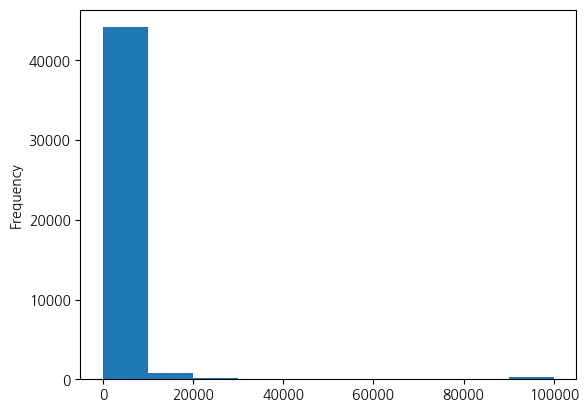


              class
capital-gain       
6418            1.0
7262            1.0
7298            1.0
7430            1.0
6097            1.0
...             ...
2387            0.0
2354            0.0
2346            0.0
2329            0.0
2907            0.0

[121 rows x 1 columns]


============================== capital-loss ==============================
capital-loss count    45222.000000
mean        88.595418
std        404.956092
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64



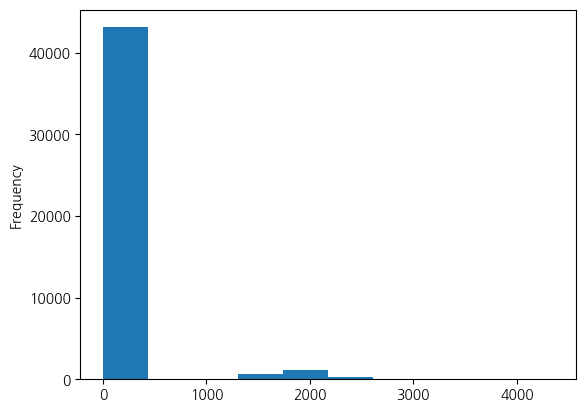


              class
capital-loss       
1564            1.0
2392            1.0
2415            1.0
2444            1.0
2246            1.0
...             ...
1617            0.0
1602            0.0
1594            0.0
1590            0.0
1719            0.0

[97 rows x 1 columns]


============================== hours-per-week ==============================
hours-per-week count    45222.000000
mean        40.938017
std         12.007508
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64



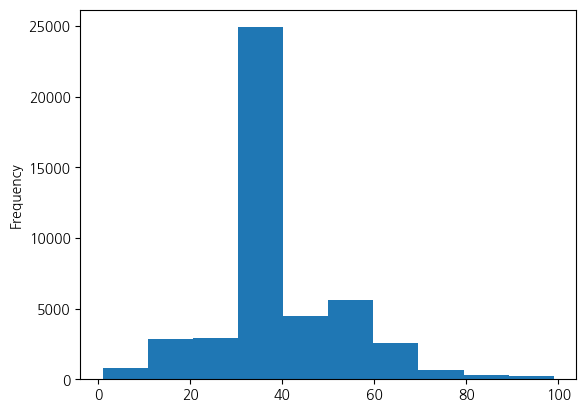


                   class
hours-per-week          
69              1.000000
76              0.750000
61              0.750000
89              0.666667
74              0.666667
...                  ...
79              0.000000
11              0.000000
82              0.000000
87              0.000000
88              0.000000

[96 rows x 1 columns]




In [39]:
# 컬럼 별로 주요한 값을 하나의 리스트에 정리 (범주형 변수와 동일)
for col in num_cols.iloc[:,:-1]:  # class 함수는 col에 제외
    print('='*30, col,'='*30)
    print(col, num_cols[col].describe())  # 값 범위 파악
    print()
    num_cols[col].plot(kind='hist')
    plt.show()
    print()
    print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    print()
    ratio_result = data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class']>0.40].index)
    print()

In [40]:
important_cols

[Index([' Self-emp-inc'], dtype='object', name='workclass'),
 Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education'),
 Index([' Married-civ-spouse', ' Married-AF-spouse'], dtype='object', name='marital-status'),
 Index([' Exec-managerial', ' Prof-specialty'], dtype='object', name='occupation'),
 Index([' Wife', ' Husband'], dtype='object', name='relationship'),
 Index([], dtype='object', name='race'),
 Index([], dtype='object', name='sex'),
 Index([' Taiwan', ' France', ' India'], dtype='object', name='native-country'),
 Index([50, 53, 51, 54, 46, 47], dtype='int64', name='age'),
 Index([15, 16, 14, 13], dtype='int64', name='education-num'),
 Index([ 6418,  7262,  7298,  7430,  6097,  7688,  5556,  8614,  9386,  9562,
        10520,  5178, 10605, 11678, 13550, 14084, 14344, 15020, 15024, 15831,
        18481, 20051,  4687,  4934, 25124, 25236, 27828,  4787, 99999,  6514,
         3103,  4386,  7896],
       dtype='int64', name='capital-gain'),

In [41]:
# 값이 있는 컬럼만 다시 정리
final_cols = []

for col in important_cols:
    if len(col) > 0:
        print(col.name, '\t',len(col))
        final_cols.append(col.name)  # 값의 컬럼 이름을 추가
        
final_cols
## groupby 연산을 했을 때 의미가 있어보이는 컬럼들을 토대로 진행

workclass 	 1
education 	 4
marital-status 	 2
occupation 	 2
relationship 	 2
native-country 	 3
age 	 6
education-num 	 4
capital-gain 	 33
capital-loss 	 26
hours-per-week 	 16


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country',
 'age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

#### education과 education-num 변수가 동일

In [42]:
data['education-num'].value_counts()

education-num
9     14783
10     9899
13     7570
14     2514
11     1959
7      1619
12     1507
6      1223
4       823
15      785
5       676
8       577
16      544
3       449
2       222
1        72
Name: count, dtype: int64

In [43]:
data['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

### 의미있는 컬럼만 추출한 데이터셋을 다시 설정

In [44]:
data_set1 = data[final_cols]
data_set1 = data_set1.drop('education', axis=1)
data_set1

,workclass,marital-status,occupation,relationship,native-country,age,education-num,capital-gain,capital-loss,hours-per-week
0,Private,Never-married,Machine-op-inspct,Own-child,United-States,25,7,0,0,40
1,Private,Married-civ-spouse,Farming-fishing,Husband,United-States,38,9,0,0,50
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,United-States,28,12,0,0,40
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,44,10,7688,0,40
4,Private,Never-married,Other-service,Not-in-family,United-States,34,6,0,0,30
...,...,...,...,...,...,...,...,...,...,...
45217,Private,Married-civ-spouse,Tech-support,Wife,United-States,27,12,0,0,38
45218,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,40,9,0,0,40
45219,Private,Widowed,Adm-clerical,Unmarried,United-States,58,9,0,0,40
45220,Private,Never-married,Adm-clerical,Own-child,United-States,22,9,0,0,20


### 수치형 변수가 아닌 애들 자동으로 one-hot 인코딩 진행
### 독립변수와 종속변수 생성

In [45]:
X = pd.get_dummies(data_set1, drop_first=True)

In [46]:
y = data['class']

#### 훈련세트, 검증세트 분류

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4, stratify=y, random_state=10)

In [49]:
X_train

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
1476,43,11,0,0,60,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34419,41,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
35870,33,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
42980,52,9,0,0,45,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40581,46,13,0,0,55,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5283,29,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1571,45,11,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33856,50,13,0,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
76,43,9,0,0,44,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [50]:
y_train.value_counts()

class
0    20408
1     6725
Name: count, dtype: int64

### 모델 훈련 진행

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [52]:
dtc = DecisionTreeClassifier(random_state = 10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.819669412350047
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     13606
           1       0.64      0.61      0.63      4483

    accuracy                           0.82     18089
   macro avg       0.76      0.75      0.75     18089
weighted avg       0.82      0.82      0.82     18089



### 모델 성능 튜닝 (하이퍼파라미터 튜닝)

In [53]:
for i in range(1,21):
    dtc = DecisionTreeClassifier(max_depth=i, random_state = 10)  # max_depth
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print("="*30,i,"="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print()

============================== 1 ==============================
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089


============================== 2 ==============================
0.8239814251755211
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13606
           1       0.72      0.47      0.57      4483

    accuracy                           0.82     18089
   macro avg       0.78      0.70      0.73     18089
weighted avg       0.81      0.82      0.81     18089


============================== 3 ==============================
0.8384653656918569
              precision    recall  f1-score   support

           0       0.86      0.94      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.86      0.94      0.90     13606
           1       0.74      0.53      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.80      0.73      0.76     18089
weighted avg       0.83      0.84      0.83     18089


============================== 5 ==============================
0.8440488694786887
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     13606
           1       0.79      0.51      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.82      0.73      0.76     18089
weighted avg       0.84      0.84      0.83     18089


============================== 6 ==============================
0.8475869312842059
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     13606
           1       0.78      0.53      0.63      4483

    accuracy  

In [54]:
dtc = DecisionTreeClassifier(max_depth=9, random_state = 10)  # max_depth
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8526728951296368
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# 의사결정나무 시각화

In [55]:
from sklearn.tree import plot_tree

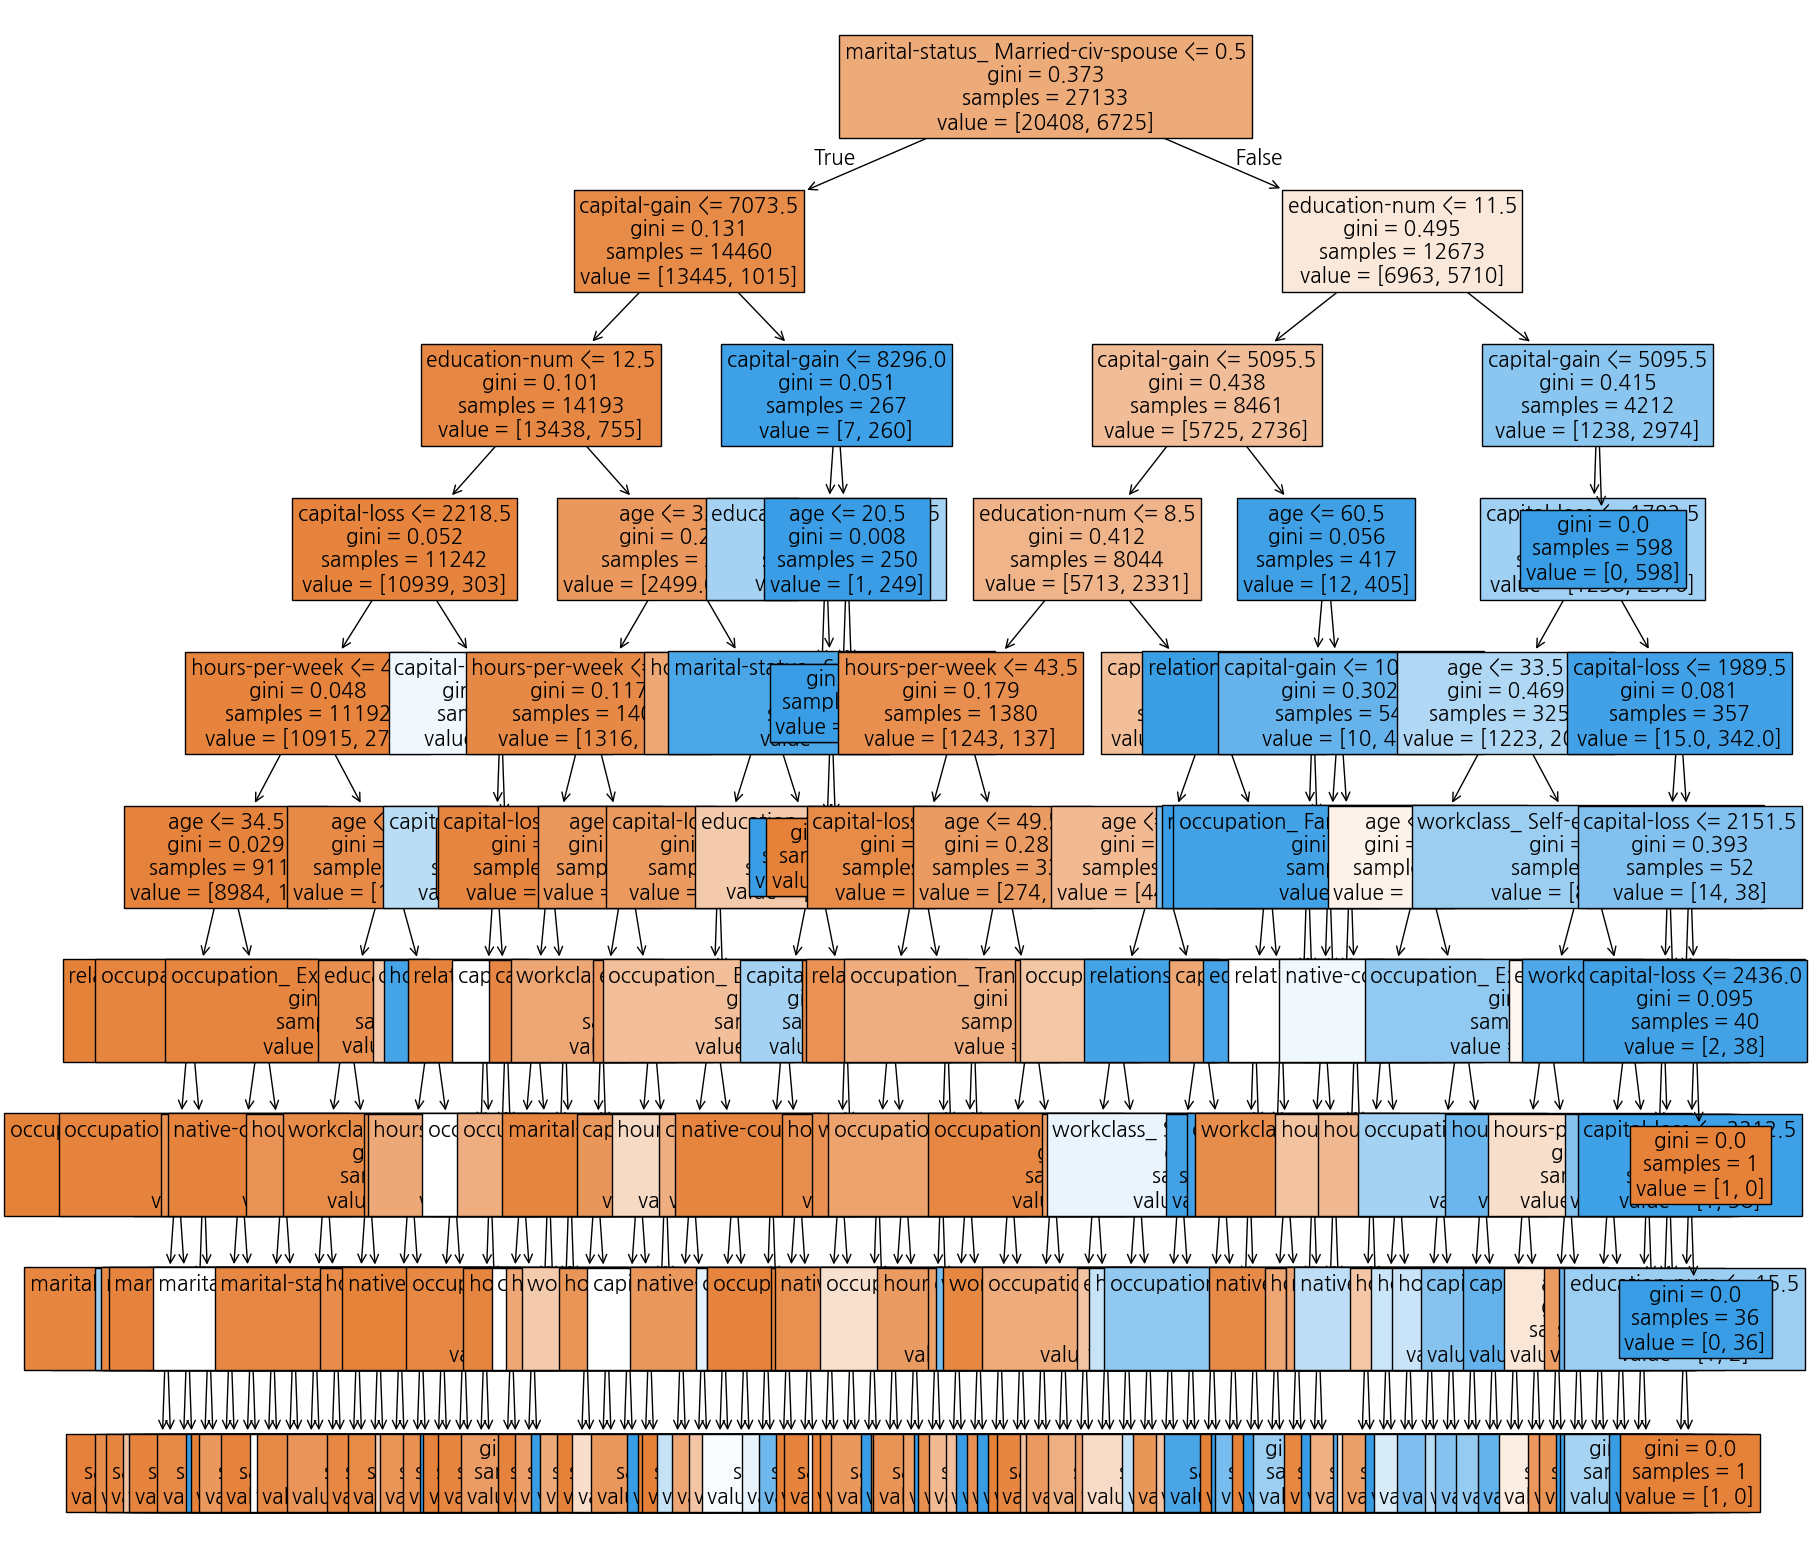

In [56]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, fontsize=15, filled=True)
plt.show()

# 데이터 분석 모델의 성능 평가

1. accuracy(정확도/정분류율): 1을 1이라고 맞추고 0을 0이라고 맞춘 비율
2. False Positive Rate(오분류율): 1을 0이라고 예측하고 0을 1이라고 예측해서 잘못 예측한 비율
3. precision(정밀도): 예측한 것 중에서 실제로 맞은 것, 예측 positive 중에서 실제 positive인 비율
4. recall(재현율/민감도): 실제값을 실제값으로 잘 예측한 것, 실제 positive 중 예측 positive가 맞은 것
5. F1-Score: precision과 recall의 조화 평균, 
6. Specificity(특이도): 실제 negative 중 예측에 성공한 비율

# confusion matrix(혼동행렬)
|               | **예측 Positive**      | **예측 Negative**       |
|:---------------:|:--------------------:|:---------------------:|
| **실제 Positive** | TP (True Positive) | FN (False Negative) |
| **실제 Negative** | FP (False Positive)| TN (True Negative)  |
* TP: 실제 Positive, 예측 Positive (실제 연봉 5만 이상, 예측 연봉 5만 이상)
* TN: 실제 Negative, 예측 Negative (실제 연봉 5만 미만, 예측 연봉 5만 미만)
* FP(1형오류): 실제 Negative, 예측 Positive(실제연봉 5만 미만, 예측 연봉 5만 이상)
* TP(2형오류): 실제 Positive, 예측 Negative(실제연봉 5만 이상, 예측 연봉 5만 미만)

* 정확도(accuracy_score): (TP+TN)/(TP+TN+FP+FN)
* 오분류율(FPR): (FP+FN) / (TP+TN+FP+TN)
* 정밀도(presicion): (TP / TP+FP)
* 재현율/민감도(recall): (TP / TP+FN)
* 특이도(Specificity): TN / (FP+TN)
* $ F1score = 2 \cdot {Precision \cdot Recall \over Precision + Recall} $

In [57]:
from sklearn.metrics import confusion_matrix

In [58]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [59]:
data_set1 = data[final_cols]
data_set1 = data_set1.drop('education', axis=1)
data_set1

,workclass,marital-status,occupation,relationship,native-country,age,education-num,capital-gain,capital-loss,hours-per-week
0,Private,Never-married,Machine-op-inspct,Own-child,United-States,25,7,0,0,40
1,Private,Married-civ-spouse,Farming-fishing,Husband,United-States,38,9,0,0,50
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,United-States,28,12,0,0,40
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,44,10,7688,0,40
4,Private,Never-married,Other-service,Not-in-family,United-States,34,6,0,0,30
...,...,...,...,...,...,...,...,...,...,...
45217,Private,Married-civ-spouse,Tech-support,Wife,United-States,27,12,0,0,38
45218,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,40,9,0,0,40
45219,Private,Widowed,Adm-clerical,Unmarried,United-States,58,9,0,0,40
45220,Private,Never-married,Adm-clerical,Own-child,United-States,22,9,0,0,20


# Dataset2: 모든 컬럼을 다 넣고 분석해보기

In [60]:
X2 = data.drop('class',axis=1)
X2

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [61]:
X2 = pd.get_dummies(X2,drop_first=True)
X2

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [62]:
X2_train, X2_test,y2_train,y2_test = train_test_split(X2,y,test_size=0.4,random_state=10)

In [63]:
dtc2 = DecisionTreeClassifier(random_state=10)
dtc2.fit(X2_train, y2_train)
pred2 = dtc2.predict(X2_test)
print(accuracy_score(y2_test,pred2))
print(classification_report(y2_test,pred2))

0.8133672397589695
              precision    recall  f1-score   support

           0       0.87      0.88      0.88     13580
           1       0.63      0.60      0.62      4509

    accuracy                           0.81     18089
   macro avg       0.75      0.74      0.75     18089
weighted avg       0.81      0.81      0.81     18089



In [64]:
for i in range(1,21):
    dtc2 = DecisionTreeClassifier(max_depth= i,random_state=10)
    dtc2.fit(X2_train, y2_train)
    pred2 = dtc2.predict(X2_test)
    print('='*30,'max_depth',i,'='*30)
    print(accuracy_score(y2_test,pred2))
    print(classification_report(y2_test,pred2))
    print()

============================== max_depth 1 ==============================
0.7507324893581735
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13580
           1       0.00      0.00      0.00      4509

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.56      0.75      0.64     18089


============================== max_depth 2 ==============================
0.8253634805683012
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13580
           1       0.73      0.48      0.58      4509

    accuracy                           0.83     18089
   macro avg       0.79      0.71      0.73     18089
weighted avg       0.82      0.83      0.81     18089


============================== max_depth 3 ==============================
0.839018187848969
              precision    recall  f1-score   support

           

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


============================== max_depth 5 ==============================
0.8468682624799602
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     13580
           1       0.77      0.55      0.64      4509

    accuracy                           0.85     18089
   macro avg       0.82      0.75      0.77     18089
weighted avg       0.84      0.85      0.84     18089


============================== max_depth 6 ==============================
0.8502404776383438
              precision    recall  f1-score   support

           0       0.86      0.95      0.91     13580
           1       0.79      0.55      0.65      4509

    accuracy                           0.85     18089
   macro avg       0.83      0.75      0.78     18089
weighted avg       0.84      0.85      0.84     18089


============================== max_depth 7 ==============================
0.8498535021283653
              precision    recall  f1-score   support

          

In [65]:
dtc2 = DecisionTreeClassifier(max_depth= 12,random_state=10)
dtc2.fit(X2_train, y2_train)
pred2 = dtc2.predict(X2_test)
print('='*30,'max_depth',i,'='*30)
print(accuracy_score(y2_test,pred2))
print(classification_report(y2_test,pred2))

============================== max_depth 20 ==============================
0.8519542263253911
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     13580
           1       0.74      0.62      0.68      4509

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089



In [66]:
# 기존
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8526728951296368
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# EDA를 간편하게 하자
* ydata

In [68]:
!pip install ydata-profiling

In [69]:
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

In [70]:
profile = ProfileReport(data,title='Profiling Report')

In [71]:
profile.to_file("salary2_eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 25.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

y-data의 결과를 통해 데이터 전처리

In [72]:
data2 = data2.dropna()

In [73]:
data2 = data2.drop_duplicates()
data2

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [74]:
data2.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [75]:
data2 = data2.drop(['education','relationship'], axis=1)

In [76]:
data2 = data2.reset_index(drop=True)

In [77]:
data2

,age,workclass,education-num,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,7,Never-married,Machine-op-inspct,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Black,Male,7688,0,40,United-States,>50K
4,34,Private,6,Never-married,Other-service,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
39235,53,Private,14,Married-civ-spouse,Exec-managerial,White,Male,0,0,40,United-States,>50K
39236,22,Private,10,Never-married,Protective-serv,White,Male,0,0,40,United-States,<=50K
39237,27,Private,12,Married-civ-spouse,Tech-support,White,Female,0,0,38,United-States,<=50K
39238,58,Private,9,Widowed,Adm-clerical,White,Female,0,0,40,United-States,<=50K


In [78]:
data2 = pd.get_dummies(data2, drop_first=True)
X3 = data2.drop("class_ >50K", axis=1)
y3 = data2['class_ >50K']

In [79]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.4, stratify=y3, random_state=10)

In [80]:
y3_train

21251    False
3994     False
1871      True
16563    False
16892     True
         ...  
15385    False
37453    False
14106    False
20368    False
36269    False
Name: class_ >50K, Length: 23544, dtype: bool

In [81]:
for i in range(1,31):
    dtc3 = DecisionTreeClassifier(max_depth = i, random_state=10)
    dtc3.fit(X3_train, y3_train)
    pred3 = dtc3.predict(X3_test)
    print(f"max_Depth:{i}", "="*30)
    print(accuracy_score(y3_test, pred3))
    print(classification_report(y3_test, pred3))

max_Depth:1 ==============================
0.7457951070336392
              precision    recall  f1-score   support

       False       0.75      1.00      0.85     11706
        True       0.00      0.00      0.00      3990

    accuracy                           0.75     15696
   macro avg       0.37      0.50      0.43     15696
weighted avg       0.56      0.75      0.64     15696

max_Depth:2 ==============================
0.8162589194699287
              precision    recall  f1-score   support

       False       0.83      0.94      0.88     11706
        True       0.73      0.44      0.55      3990

    accuracy                           0.82     15696
   macro avg       0.78      0.69      0.72     15696
weighted avg       0.81      0.82      0.80     15696

max_Depth:3 ==============================
0.8333333333333334


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       False       0.85      0.94      0.89     11706
        True       0.75      0.51      0.61      3990

    accuracy                           0.83     15696
   macro avg       0.80      0.73      0.75     15696
weighted avg       0.83      0.83      0.82     15696

max_Depth:4 ==============================
0.8336518858307849
              precision    recall  f1-score   support

       False       0.85      0.94      0.89     11706
        True       0.75      0.51      0.61      3990

    accuracy                           0.83     15696
   macro avg       0.80      0.73      0.75     15696
weighted avg       0.83      0.83      0.82     15696

max_Depth:5 ==============================
0.8418068297655453
              precision    recall  f1-score   support

       False       0.85      0.95      0.90     11706
        True       0.78      0.52      0.63      3990

    accuracy                           0.84     15696
   m

              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.65      0.62      0.63      3990

    accuracy                           0.82     15696
   macro avg       0.76      0.75      0.76     15696
weighted avg       0.82      0.82      0.82     15696

max_Depth:26 ==============================
0.816322629969419
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.64      0.62      0.63      3990

    accuracy                           0.82     15696
   macro avg       0.76      0.75      0.76     15696
weighted avg       0.81      0.82      0.82     15696

max_Depth:27 ==============================
0.8152395514780836
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     11706
        True       0.64      0.62      0.63      3990

    accuracy                           0.82     15696
   

In [82]:
dtc3 = DecisionTreeClassifier(max_depth=8, random_state=10)
dtc3.fit(X3_train, y3_train)
pred3 = dtc3.predict(X3_test)
print(accuracy_score(y3_test, pred3))
print(classification_report(y3_test, pred3))

0.8476681957186545
              precision    recall  f1-score   support

       False       0.87      0.93      0.90     11706
        True       0.75      0.60      0.67      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.77      0.78     15696
weighted avg       0.84      0.85      0.84     15696



In [83]:
print(classification_report(y_test, pred))
print(classification_report(y2_test, pred2))
print(classification_report(y3_test, pred3))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     13580
           1       0.74      0.62      0.68      4509

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089

              precision    recall  f1-score   support

       False       0.87      0.93      0.90     11706
        True       0.75      0.60      0.67      3990

    accuracy                           0.85     15696
   macro avg       0.81      0.77      0.78     15696
weighted avg       0.84      0.85      0.84     15696



In [84]:
len(data)

45222

# 배깅, 부스팅, 랜덤 배깅

# 배깅
* 데이터셋에서 복원추출방법으로 부트스트랩을 여러개 만들고 각각의 부트스트랩을 분류기 (의사결정나무)에 넣고 나온 결과를 다수결로 결정하는 방법
* 독립된 부트스트랩, 독립된 모델로 결과 도출
* 투표를 통해 결정

In [85]:
from sklearn.ensemble import BaggingClassifier

In [86]:
bc = BaggingClassifier(n_estimators=10, n_jobs=10, random_state=10)
bc.fit(X_train, y_train)
pred = bc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8393498811432363
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     13606
           1       0.71      0.60      0.65      4483

    accuracy                           0.84     18089
   macro avg       0.79      0.76      0.77     18089
weighted avg       0.83      0.84      0.84     18089



In [87]:
est = DecisionTreeClassifier(max_depth=9, random_state=10)
bc = BaggingClassifier(estimator=est, n_estimators=100, n_jobs=10, random_state=10)
bc.fit(X_train, y_train)
pred = bc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8596384543092487
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.79      0.60      0.68      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.77      0.79     18089
weighted avg       0.85      0.86      0.85     18089



# 부스팅
* 처음 만든 부트스트랩을 분석한 후 정답은 제외하고 틀린 것만 모아서 다시 부트스트랩 만들고 공부 후 틀린 것을 다시 공부하는 것.
* 점진적으로 성능이 향상되는 알고리즘
* XGBoost, LightGBM, Catboost

In [88]:
from sklearn.ensemble import AdaBoostClassifier

In [89]:
abc = AdaBoostClassifier(n_estimators=500, learning_rate=0.5 ,random_state=10)
abc.fit(X_train, y_train)
pred = abc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8541655149538393
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     13606
           1       0.79      0.57      0.66      4483

    accuracy                           0.85     18089
   macro avg       0.83      0.76      0.78     18089
weighted avg       0.85      0.85      0.85     18089



In [90]:
from sklearn.ensemble import GradientBoostingClassifier

In [91]:
gbc = GradientBoostingClassifier(n_estimators=100, random_state=10)
gbc.fit(X_train, y_train)
pred = gbc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8646138537232573
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.80      0.60      0.69      4483

    accuracy                           0.86     18089
   macro avg       0.84      0.78      0.80     18089
weighted avg       0.86      0.86      0.86     18089



# XGBOOST
* 병렬연산이 가능해서 처리 속도가 매우 빨라짐
* 따로 설치 필요

In [92]:
from xgboost import XGBClassifier

In [93]:
xgb = XGBClassifier(max_depth=9, n_estimators=100, random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8668804245674167
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     13606
           1       0.77      0.65      0.71      4483

    accuracy                           0.87     18089
   macro avg       0.83      0.79      0.81     18089
weighted avg       0.86      0.87      0.86     18089



In [94]:
for i in range(1, 20):
    xgb = XGBClassifier(max_depth=i, n_estimators=100, n_jobs=10, random_state=10)
    xgb.fit(X_train, y_train)
    pred = xgb.predict(X_test)
    print(i)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

1
0.8572613190336669
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     13606
           1       0.80      0.57      0.66      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.76      0.79     18089
weighted avg       0.85      0.86      0.85     18089

2
0.8653878047432141
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     13606
           1       0.79      0.62      0.69      4483

    accuracy                           0.87     18089
   macro avg       0.84      0.78      0.80     18089
weighted avg       0.86      0.87      0.86     18089

3
0.8687600199015977
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     13606
           1       0.80      0.63      0.70      4483

    accuracy                           0.87     18089
   macro avg       0.84      0.79      0.81     18089
weighted av

In [95]:
%%time
xgb = XGBClassifier(max_depth=8, n_estimators=1000, n_jobs=10, random_state=10)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.853004588423904
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     13606
           1       0.73      0.64      0.68      4483

    accuracy                           0.85     18089
   macro avg       0.81      0.78      0.79     18089
weighted avg       0.85      0.85      0.85     18089

CPU times: user 33 s, sys: 24.1 ms, total: 33 s
Wall time: 4.3 s


# LightGBM
* xgboost보다 속도를 더 빠르게
* 비대칭 트리를 만듦

In [96]:
from lightgbm import LGBMClassifier

In [97]:
%%time
lgbm = LGBMClassifier(n_estimators=1000, n_jobs=10, random_state=10)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6725, number of negative: 20408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 452
[LightGBM] [Info] Number of data points in the train set: 27133, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.247853 -> initscore=-1.110095
[LightGBM] [Info] Start training from score -1.110095
0.8635082094090332
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     13606
           1       0.76      0.65      0.70      4483

    accuracy                           0.86     18089
   macro avg       0.83      0.79      0.81     18089
weighted avg       0.86      0.86      0.86     18089

CPU times: user 22

In [98]:
from catboost import CatBoostClassifier

In [99]:
%%time
cbc = CatBoostClassifier(n_estimators=1000, random_state=10)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Learning rate set to 0.042173
0:	learn: 0.6536390	total: 75.7ms	remaining: 1m 15s
1:	learn: 0.6161668	total: 86.4ms	remaining: 43.1s
2:	learn: 0.5857310	total: 90.5ms	remaining: 30.1s
3:	learn: 0.5573898	total: 93.8ms	remaining: 23.4s
4:	learn: 0.5306863	total: 97.3ms	remaining: 19.4s
5:	learn: 0.5082347	total: 100ms	remaining: 16.6s
6:	learn: 0.4879174	total: 103ms	remaining: 14.7s
7:	learn: 0.4698112	total: 106ms	remaining: 13.2s
8:	learn: 0.4547847	total: 110ms	remaining: 12.1s
9:	learn: 0.4419169	total: 113ms	remaining: 11.2s
10:	learn: 0.4304874	total: 116ms	remaining: 10.4s
11:	learn: 0.4204120	total: 119ms	remaining: 9.81s
12:	learn: 0.4107632	total: 123ms	remaining: 9.33s
13:	learn: 0.4026859	total: 126ms	remaining: 8.89s
14:	learn: 0.3967674	total: 129ms	remaining: 8.49s
15:	learn: 0.3901975	total: 132ms	remaining: 8.15s
16:	learn: 0.3843148	total: 136ms	remaining: 7.85s
17:	learn: 0.3784273	total: 139ms	remaining: 7.58s
18:	learn: 0.3731993	total: 144ms	remaining: 7.43s
19:	l

169:	learn: 0.2927865	total: 1s	remaining: 4.89s
170:	learn: 0.2926790	total: 1.01s	remaining: 4.89s
171:	learn: 0.2925732	total: 1.02s	remaining: 4.89s
172:	learn: 0.2924239	total: 1.02s	remaining: 4.9s
173:	learn: 0.2923308	total: 1.04s	remaining: 4.95s
174:	learn: 0.2922354	total: 1.05s	remaining: 4.98s
175:	learn: 0.2921539	total: 1.07s	remaining: 5.02s
176:	learn: 0.2920843	total: 1.08s	remaining: 5.02s
177:	learn: 0.2920267	total: 1.09s	remaining: 5.02s
178:	learn: 0.2919792	total: 1.09s	remaining: 5.02s
179:	learn: 0.2918657	total: 1.1s	remaining: 5.02s
180:	learn: 0.2917583	total: 1.11s	remaining: 5.01s
181:	learn: 0.2916325	total: 1.12s	remaining: 5.02s
182:	learn: 0.2914916	total: 1.12s	remaining: 5.01s
183:	learn: 0.2914015	total: 1.13s	remaining: 5s
184:	learn: 0.2913665	total: 1.13s	remaining: 4.99s
185:	learn: 0.2910889	total: 1.14s	remaining: 4.98s
186:	learn: 0.2909906	total: 1.15s	remaining: 4.99s
187:	learn: 0.2908143	total: 1.15s	remaining: 4.98s
188:	learn: 0.290703

328:	learn: 0.2790504	total: 1.84s	remaining: 3.75s
329:	learn: 0.2789970	total: 1.84s	remaining: 3.75s
330:	learn: 0.2789445	total: 1.85s	remaining: 3.74s
331:	learn: 0.2788819	total: 1.86s	remaining: 3.73s
332:	learn: 0.2788150	total: 1.87s	remaining: 3.75s
333:	learn: 0.2787397	total: 1.88s	remaining: 3.75s
334:	learn: 0.2786986	total: 1.88s	remaining: 3.74s
335:	learn: 0.2786434	total: 1.89s	remaining: 3.74s
336:	learn: 0.2785921	total: 1.9s	remaining: 3.74s
337:	learn: 0.2785427	total: 1.9s	remaining: 3.73s
338:	learn: 0.2785126	total: 1.91s	remaining: 3.72s
339:	learn: 0.2784524	total: 1.92s	remaining: 3.72s
340:	learn: 0.2783734	total: 1.92s	remaining: 3.72s
341:	learn: 0.2782396	total: 1.93s	remaining: 3.71s
342:	learn: 0.2781696	total: 1.93s	remaining: 3.7s
343:	learn: 0.2781192	total: 1.94s	remaining: 3.69s
344:	learn: 0.2779397	total: 1.94s	remaining: 3.68s
345:	learn: 0.2778869	total: 1.94s	remaining: 3.67s
346:	learn: 0.2778383	total: 1.95s	remaining: 3.67s
347:	learn: 0.2

525:	learn: 0.2679462	total: 2.67s	remaining: 2.4s
526:	learn: 0.2679046	total: 2.67s	remaining: 2.4s
527:	learn: 0.2678682	total: 2.68s	remaining: 2.39s
528:	learn: 0.2678200	total: 2.68s	remaining: 2.39s
529:	learn: 0.2677737	total: 2.69s	remaining: 2.38s
530:	learn: 0.2677081	total: 2.69s	remaining: 2.38s
531:	learn: 0.2676742	total: 2.7s	remaining: 2.37s
532:	learn: 0.2676162	total: 2.7s	remaining: 2.37s
533:	learn: 0.2675975	total: 2.7s	remaining: 2.36s
534:	learn: 0.2675184	total: 2.71s	remaining: 2.35s
535:	learn: 0.2675035	total: 2.71s	remaining: 2.35s
536:	learn: 0.2674555	total: 2.72s	remaining: 2.34s
537:	learn: 0.2674081	total: 2.72s	remaining: 2.34s
538:	learn: 0.2673497	total: 2.72s	remaining: 2.33s
539:	learn: 0.2673072	total: 2.73s	remaining: 2.32s
540:	learn: 0.2672759	total: 2.73s	remaining: 2.32s
541:	learn: 0.2672452	total: 2.73s	remaining: 2.31s
542:	learn: 0.2671956	total: 2.74s	remaining: 2.31s
543:	learn: 0.2671574	total: 2.74s	remaining: 2.3s
544:	learn: 0.2671

709:	learn: 0.2617437	total: 3.52s	remaining: 1.44s
710:	learn: 0.2616797	total: 3.52s	remaining: 1.43s
711:	learn: 0.2616280	total: 3.53s	remaining: 1.43s
712:	learn: 0.2616064	total: 3.54s	remaining: 1.42s
713:	learn: 0.2615676	total: 3.54s	remaining: 1.42s
714:	learn: 0.2615292	total: 3.54s	remaining: 1.41s
715:	learn: 0.2615044	total: 3.55s	remaining: 1.41s
716:	learn: 0.2614725	total: 3.55s	remaining: 1.4s
717:	learn: 0.2614449	total: 3.56s	remaining: 1.4s
718:	learn: 0.2614167	total: 3.56s	remaining: 1.39s
719:	learn: 0.2613952	total: 3.56s	remaining: 1.39s
720:	learn: 0.2613625	total: 3.57s	remaining: 1.38s
721:	learn: 0.2613133	total: 3.57s	remaining: 1.37s
722:	learn: 0.2612932	total: 3.57s	remaining: 1.37s
723:	learn: 0.2612339	total: 3.58s	remaining: 1.36s
724:	learn: 0.2612039	total: 3.58s	remaining: 1.36s
725:	learn: 0.2611891	total: 3.58s	remaining: 1.35s
726:	learn: 0.2611518	total: 3.59s	remaining: 1.35s
727:	learn: 0.2611191	total: 3.6s	remaining: 1.34s
728:	learn: 0.2

906:	learn: 0.2556618	total: 4.72s	remaining: 484ms
907:	learn: 0.2556374	total: 4.72s	remaining: 479ms
908:	learn: 0.2556301	total: 4.73s	remaining: 473ms
909:	learn: 0.2555772	total: 4.73s	remaining: 468ms
910:	learn: 0.2555311	total: 4.74s	remaining: 463ms
911:	learn: 0.2555046	total: 4.75s	remaining: 459ms
912:	learn: 0.2554642	total: 4.76s	remaining: 454ms
913:	learn: 0.2554384	total: 4.76s	remaining: 448ms
914:	learn: 0.2553877	total: 4.77s	remaining: 443ms
915:	learn: 0.2553798	total: 4.78s	remaining: 438ms
916:	learn: 0.2553440	total: 4.78s	remaining: 433ms
917:	learn: 0.2553312	total: 4.79s	remaining: 428ms
918:	learn: 0.2552904	total: 4.8s	remaining: 423ms
919:	learn: 0.2552795	total: 4.8s	remaining: 418ms
920:	learn: 0.2552442	total: 4.81s	remaining: 412ms
921:	learn: 0.2552361	total: 4.81s	remaining: 407ms
922:	learn: 0.2552070	total: 4.82s	remaining: 402ms
923:	learn: 0.2551423	total: 4.82s	remaining: 396ms
924:	learn: 0.2551361	total: 4.82s	remaining: 391ms
925:	learn: 0.

# 랜덤 배깅 (RandomForest)

In [100]:
from sklearn.ensemble import RandomForestClassifier

In [101]:
%%time
rfc = RandomForestClassifier(n_estimators=1000, n_jobs=10, random_state=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8490242688926972
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     13606
           1       0.73      0.63      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.80      0.77      0.79     18089
weighted avg       0.84      0.85      0.85     18089

CPU times: user 55.3 s, sys: 2.39 s, total: 57.7 s
Wall time: 8.95 s


In [102]:
for i in range(1, 21):
    rfc = RandomForestClassifier(max_depth= i, n_estimators=1000, n_jobs=10, random_state=10)
    rfc.fit(X_train, y_train)
    pred = rfc.predict(X_test)
    print(i)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

1
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


2
0.7624523190889491
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     13606
           1       0.99      0.04      0.08      4483

    accuracy                           0.76     18089
   macro avg       0.88      0.52      0.47     18089
weighted avg       0.82      0.76      0.67     18089

3
0.7853944386090994
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     13606
           1       1.00      0.13      0.24      4483

    accuracy                           0.79     18089
   macro avg       0.89      0.57      0.56     18089
weighted avg       0.83      0.79      0.72     18089

4
0.8089999447177842
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     13606
           1       0.96      0.24      0.38      4483

    accuracy                           0.81     18089
   macro avg       0.88      0.62      0.64     18089
weighted av